# Bước 7: Xử Lý Ngoại Lệ (Handling Outliers)

Ngoại lệ là các điểm dữ liệu khác biệt đáng kể so với phần còn lại.

**Mục tiêu:**
- Phát hiện outliers bằng phương pháp IQR
- Trực quan hóa outliers
- Đề xuất và thực hiện xử lý

## 7.1 Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Thư viện đã được import thành công!")

✅ Thư viện đã được import thành công!


## 7.2 Tải dữ liệu

In [2]:
try:
    df = pd.read_pickle('outputs/df_step5.pkl')
    print("✅ Đã tải dữ liệu từ Bước 5")
except:
    DATA_PATH = Path("../data/raw/accepted_2007_to_2018Q4.csv")
    df = pd.read_csv(DATA_PATH, nrows=50000, low_memory=False)
    print("📂 Đã tải dữ liệu gốc")

print(f"📊 Kích thước: {df.shape[0]:,} hàng × {df.shape[1]} cột")
n_rows = len(df)

# Chọn biến số để phân tích outliers
num_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 
            'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc']
num_cols = [col for col in num_cols if col in df.columns]

print(f"🔢 Phân tích {len(num_cols)} biến số: {num_cols}")

✅ Đã tải dữ liệu từ Bước 5
📊 Kích thước: 50,000 hàng × 155 cột
🔢 Phân tích 9 biến số: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc', 'revol_bal', 'revol_util', 'total_acc']


## 7.3 Phương pháp IQR để phát hiện Outliers

In [3]:
print("=" * 70)
print("📊 PHƯƠNG PHÁP IQR (Interquartile Range)")
print("=" * 70)
print("""
Công thức:
• Q1 = quantile(0.25) - điểm 25%
• Q3 = quantile(0.75) - điểm 75%
• IQR = Q3 - Q1 (khoảng tứ phân vị)
• Ngoại lệ: giá trị < Q1 - 1.5*IQR hoặc > Q3 + 1.5*IQR
""")

📊 PHƯƠNG PHÁP IQR (Interquartile Range)

Công thức:
• Q1 = quantile(0.25) - điểm 25%
• Q3 = quantile(0.75) - điểm 75%
• IQR = Q3 - Q1 (khoảng tứ phân vị)
• Ngoại lệ: giá trị < Q1 - 1.5*IQR hoặc > Q3 + 1.5*IQR



In [4]:
# Tính toán outliers cho từng biến
outlier_stats = []
outlier_bounds = {}

for col in num_cols:
    data = df[col].dropna()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Đếm outliers
    lower_outliers = (data < lower_bound).sum()
    upper_outliers = (data > upper_bound).sum()
    total_outliers = lower_outliers + upper_outliers
    pct_outliers = total_outliers / len(data) * 100
    
    outlier_stats.append({
        'Cột': col,
        'Min': data.min(),
        'Q1': Q1,
        'Median': data.median(),
        'Q3': Q3,
        'Max': data.max(),
        'Biên dưới': lower_bound,
        'Biên trên': upper_bound,
        'Outliers dưới': lower_outliers,
        'Outliers trên': upper_outliers,
        'Tổng outliers': total_outliers,
        'Tỷ lệ %': pct_outliers
    })
    outlier_bounds[col] = (lower_bound, upper_bound)

outlier_df = pd.DataFrame(outlier_stats)
print(outlier_df[['Cột', 'Min', 'Q1', 'Median', 'Q3', 'Max', 'Biên dưới', 'Biên trên', 'Tổng outliers', 'Tỷ lệ %']].to_string(index=False))

# Tính tổng
total_outliers_all = outlier_df['Tổng outliers'].sum()
max_outlier_col = outlier_df.loc[outlier_df['Tỷ lệ %'].idxmax(), 'Cột']
max_outlier_pct = outlier_df['Tỷ lệ %'].max()

print(f"\n📊 TỔNG HỢP:")
print(f"   • Tổng outliers phát hiện: {total_outliers_all:,}")
print(f"   • Biến có nhiều outliers nhất: {max_outlier_col} ({max_outlier_pct:.2f}%)")

        Cột     Min       Q1   Median         Q3        Max    Biên dưới    Biên trên  Tổng outliers  Tỷ lệ %
  loan_amnt 1000.00  8000.00 14000.00 20000.0000   35000.00 -10000.00000  38000.00000              0 0.000000
   int_rate    5.32     9.17    11.99    14.4800      28.99      1.20500     22.44500            941 1.882000
installment   14.77   255.04   378.15   573.7025    1354.66   -222.95375   1051.69625           1332 2.664000
 annual_inc    0.00 48000.00 66000.00 95000.0000 9000000.00 -22500.00000 165500.00000           2146 4.292000
        dti    0.00    12.68    18.82    25.6150     999.00     -6.72250     45.01750             28 0.056001
   open_acc    1.00     8.00    11.00    15.0000      67.00     -2.50000     25.50000           1359 2.718000
  revol_bal    0.00  6240.00 11828.00 21333.2500  898146.00 -16399.87500  43973.12500           3077 6.154000
 revol_util    0.00    34.10    52.00    70.5000     145.80    -20.50000    125.10000              4 0.008000
  total_ac

## 7.4 Trực quan hóa Outliers bằng Boxplot

📊 BOXPLOT - PHÁT HIỆN OUTLIERS


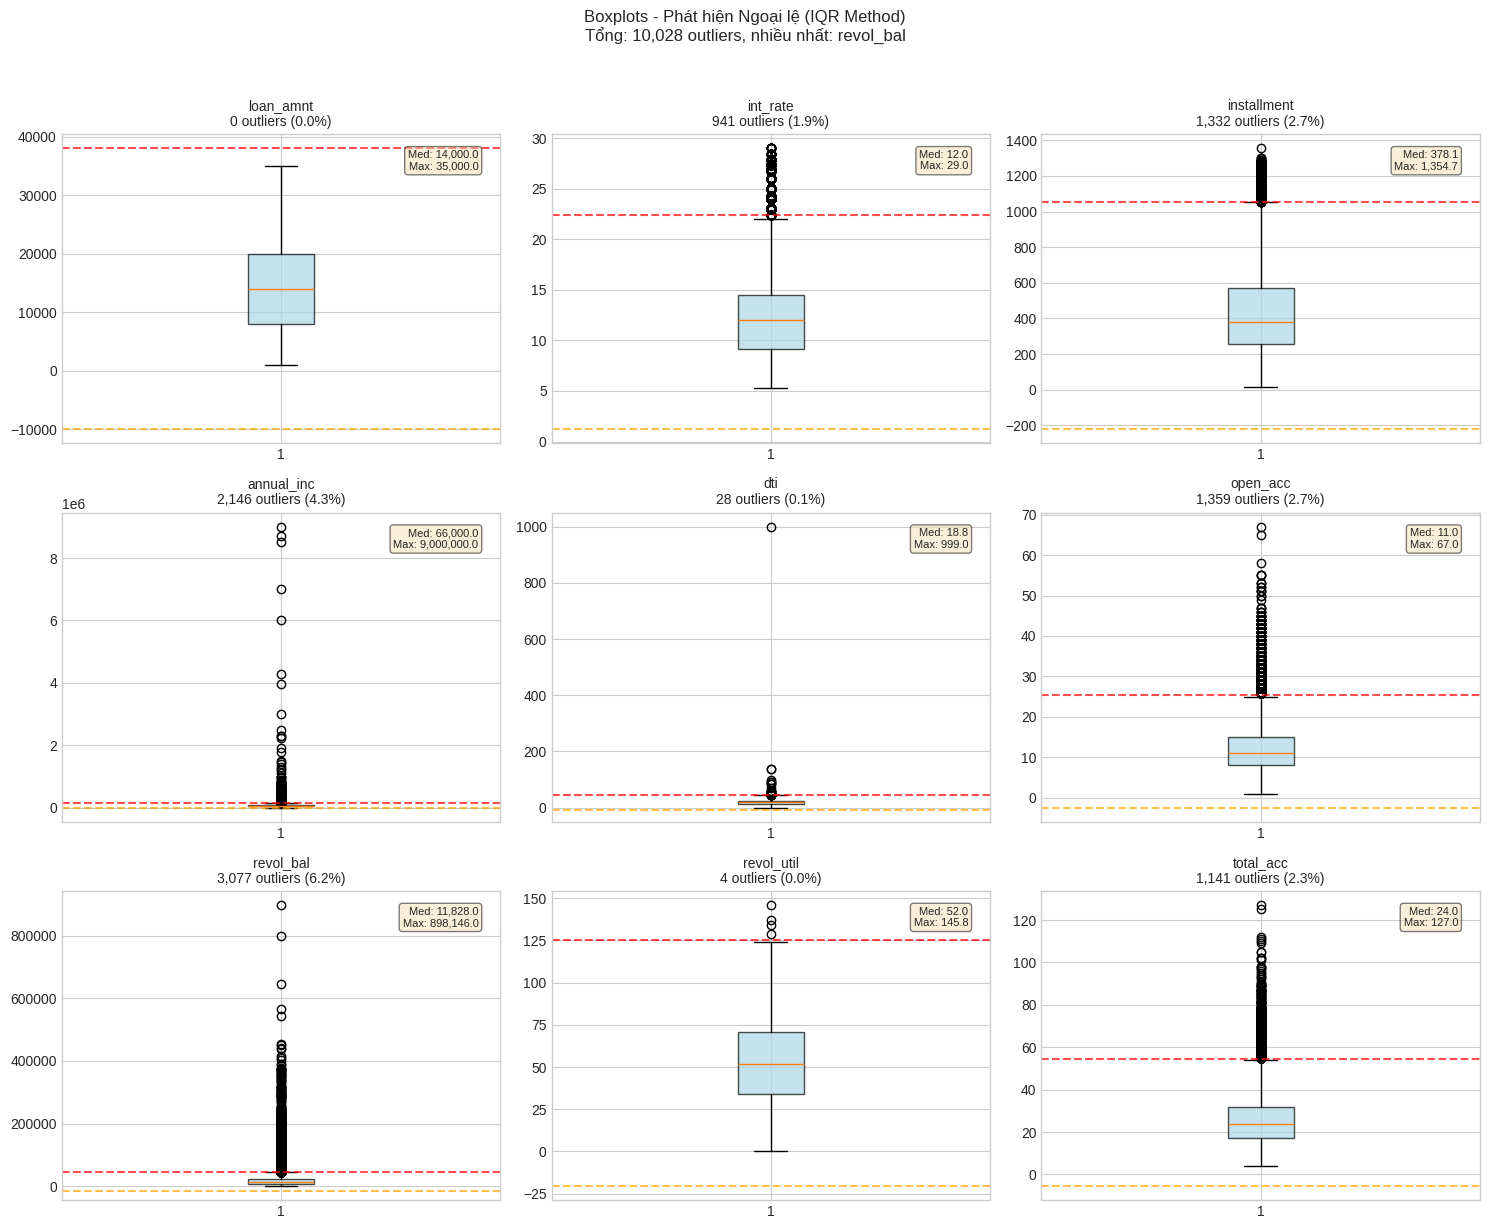

In [5]:
print("=" * 70)
print("📊 BOXPLOT - PHÁT HIỆN OUTLIERS")
print("=" * 70)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    data = df[col].dropna()
    lower, upper = outlier_bounds[col]
    pct = outlier_df[outlier_df['Cột'] == col]['Tỷ lệ %'].values[0]
    n_outliers = outlier_df[outlier_df['Cột'] == col]['Tổng outliers'].values[0]
    
    # Boxplot
    bp = ax.boxplot(data, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_alpha(0.7)
    
    # Thêm đường biên
    ax.axhline(lower, color='orange', linestyle='--', alpha=0.7, 
               label=f'Biên dưới: {lower:.1f}')
    ax.axhline(upper, color='red', linestyle='--', alpha=0.7, 
               label=f'Biên trên: {upper:.1f}')
    
    # Title với thông tin
    ax.set_title(f'{col}\n{n_outliers:,} outliers ({pct:.1f}%)', fontsize=10)
    
    # Thêm text box với thống kê
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    stats_text = f'Med: {data.median():,.1f}\nMax: {data.max():,.1f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right', bbox=props)

# Ẩn subplot thừa
for i in range(len(num_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(f'Boxplots - Phát hiện Ngoại lệ (IQR Method)\n'
             f'Tổng: {total_outliers_all:,} outliers, nhiều nhất: {max_outlier_col}', 
             y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('outputs/07_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.5 Phân tích chi tiết annual_inc

📊 PHÂN TÍCH CHI TIẾT: annual_inc

Thống kê annual_inc:
   • Số quan sát: 50,000
   • Min: $0
   • Q1: $48,000
   • Median: $66,000
   • Q3: $95,000
   • Max: $9,000,000

Outliers:
   • Biên dưới: $-22,500
   • Biên trên: $165,500
   • Số outliers cao: 2,146 (thu nhập > $165,500)
   • Số outliers thấp: 0 (thu nhập < $-22,500)

Top 5 thu nhập cao nhất:

   1. $9,000,000
   2. $8,700,000
   3. $8,500,021
   4. $7,000,000
   5. $6,000,000


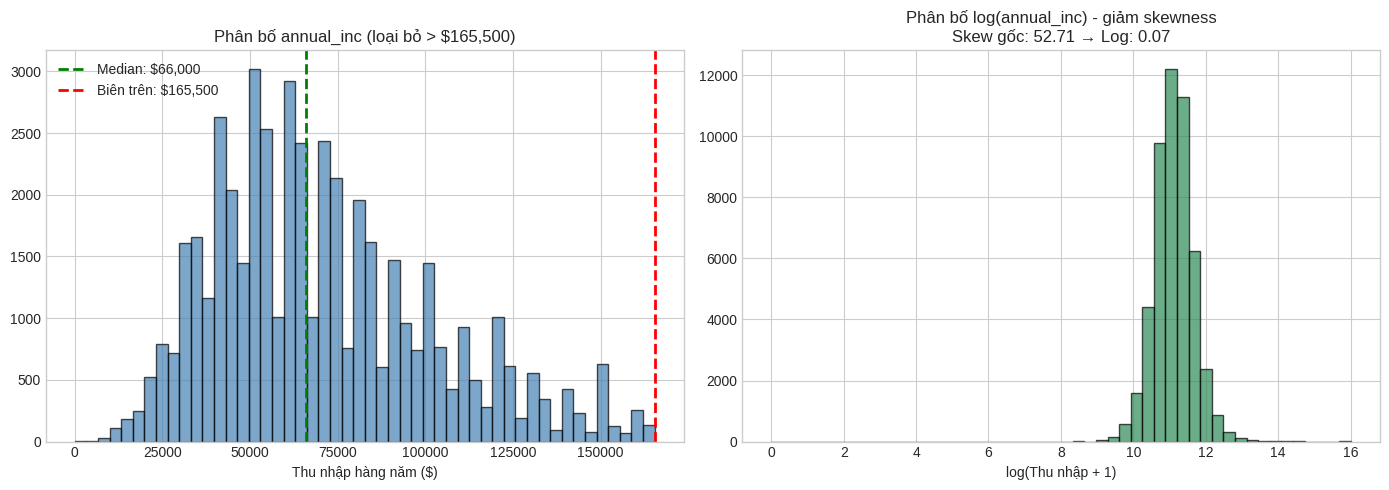

In [6]:
# Phân tích annual_inc (thường có nhiều outliers)
if 'annual_inc' in df.columns:
    print("=" * 70)
    print("📊 PHÂN TÍCH CHI TIẾT: annual_inc")
    print("=" * 70)
    
    data = df['annual_inc'].dropna()
    lower, upper = outlier_bounds['annual_inc']
    
    high_income = data[data > upper]
    low_income = data[data < lower]
    
    print(f"""
Thống kê annual_inc:
   • Số quan sát: {len(data):,}
   • Min: ${data.min():,.0f}
   • Q1: ${data.quantile(0.25):,.0f}
   • Median: ${data.median():,.0f}
   • Q3: ${data.quantile(0.75):,.0f}
   • Max: ${data.max():,.0f}
   
Outliers:
   • Biên dưới: ${lower:,.0f}
   • Biên trên: ${upper:,.0f}
   • Số outliers cao: {len(high_income):,} (thu nhập > ${upper:,.0f})
   • Số outliers thấp: {len(low_income):,} (thu nhập < ${lower:,.0f})

Top 5 thu nhập cao nhất:
""")
    for i, val in enumerate(data.nlargest(5).values, 1):
        print(f"   {i}. ${val:,.0f}")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    ax.hist(data[data < upper], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=2, 
               label=f'Median: ${data.median():,.0f}')
    ax.axvline(upper, color='red', linestyle='--', linewidth=2, 
               label=f'Biên trên: ${upper:,.0f}')
    ax.set_title(f'Phân bố annual_inc (loại bỏ > ${upper:,.0f})')
    ax.set_xlabel('Thu nhập hàng năm ($)')
    ax.legend()
    
    ax = axes[1]
    ax.hist(np.log1p(data), bins=50, color='seagreen', edgecolor='black', alpha=0.7)
    ax.set_title(f'Phân bố log(annual_inc) - giảm skewness\nSkew gốc: {data.skew():.2f} → Log: {np.log1p(data).skew():.2f}')
    ax.set_xlabel('log(Thu nhập + 1)')
    
    plt.tight_layout()
    plt.savefig('outputs/07_annual_inc_detail.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7.6 Chiến lược xử lý Outliers

In [7]:
print("=" * 70)
print("💡 CHIẾN LƯỢC XỬ LÝ OUTLIERS")
print("=" * 70)

# Phân loại khuyến nghị
recommendations = []
for _, row in outlier_df.iterrows():
    col = row['Cột']
    pct = row['Tỷ lệ %']
    
    if pct < 1:
        rec = "✅ Giữ nguyên (ít outliers)"
        action = "KEEP"
    elif pct < 3:
        rec = "⚡ Winsorization (cắt biên)"
        action = "WINSORIZE"
    elif pct < 5:
        rec = "⚡ Log transform + Winsorization"
        action = "TRANSFORM"
    else:
        rec = "⚠️ Kiểm tra chất lượng dữ liệu"
        action = "INVESTIGATE"
    
    recommendations.append({
        'Biến': col,
        'Outliers %': pct,
        'Khuyến nghị': rec,
        'Action': action
    })

rec_df = pd.DataFrame(recommendations)
print(rec_df[['Biến', 'Outliers %', 'Khuyến nghị']].to_string(index=False))

print("""
📋 GIẢI THÍCH CÁC PHƯƠNG PHÁP:

1️⃣ GIỮ NGUYÊN (KEEP):
   • Khi outliers < 1% và là dữ liệu thực
   • VD: loan_amnt không có outliers theo IQR

2️⃣ WINSORIZATION:
   • Thay giá trị outliers bằng giá trị biên (Q1-1.5*IQR hoặc Q3+1.5*IQR)
   • Giữ được tất cả dữ liệu, giảm ảnh hưởng extreme values

3️⃣ LOG TRANSFORM:
   • Cho biến có phân bố lệch mạnh (annual_inc)
   • Nén khoảng cách giữa các giá trị

4️⃣ INVESTIGATE:
   • Khi có quá nhiều outliers
   • Có thể là vấn đề chất lượng dữ liệu
""")

💡 CHIẾN LƯỢC XỬ LÝ OUTLIERS
       Biến  Outliers %                     Khuyến nghị
  loan_amnt    0.000000      ✅ Giữ nguyên (ít outliers)
   int_rate    1.882000      ⚡ Winsorization (cắt biên)
installment    2.664000      ⚡ Winsorization (cắt biên)
 annual_inc    4.292000 ⚡ Log transform + Winsorization
        dti    0.056001      ✅ Giữ nguyên (ít outliers)
   open_acc    2.718000      ⚡ Winsorization (cắt biên)
  revol_bal    6.154000  ⚠️ Kiểm tra chất lượng dữ liệu
 revol_util    0.008000      ✅ Giữ nguyên (ít outliers)
  total_acc    2.282000      ⚡ Winsorization (cắt biên)

📋 GIẢI THÍCH CÁC PHƯƠNG PHÁP:

1️⃣ GIỮ NGUYÊN (KEEP):
   • Khi outliers < 1% và là dữ liệu thực
   • VD: loan_amnt không có outliers theo IQR

2️⃣ WINSORIZATION:
   • Thay giá trị outliers bằng giá trị biên (Q1-1.5*IQR hoặc Q3+1.5*IQR)
   • Giữ được tất cả dữ liệu, giảm ảnh hưởng extreme values

3️⃣ LOG TRANSFORM:
   • Cho biến có phân bố lệch mạnh (annual_inc)
   • Nén khoảng cách giữa các giá trị

4️⃣ INVE

## 7.7 Thực hiện Winsorization

In [8]:
print("=" * 70)
print("🔧 THỰC HIỆN WINSORIZATION")
print("=" * 70)

df_clean = df.copy()
changes_made = []

for col in num_cols:
    lower, upper = outlier_bounds[col]
    before = df_clean[col].copy()
    
    # Đếm trước khi thay đổi
    n_lower = (before < lower).sum()
    n_upper = (before > upper).sum()
    
    # Áp dụng cắt biên
    df_clean[col] = df_clean[col].clip(lower, upper)
    
    # Đếm số thay đổi
    changed = (before != df_clean[col]).sum()
    if changed > 0:
        changes_made.append({
            'Biến': col,
            'Cắt dưới': n_lower,
            'Cắt trên': n_upper,
            'Tổng thay đổi': changed,
            'Biên': f'[{lower:.1f}, {upper:.1f}]'
        })
        print(f"✅ {col}: {changed:,} giá trị đã cắt biên → [{lower:.1f}, {upper:.1f}]")

if changes_made:
    print(f"\n📊 Tổng: {sum(c['Tổng thay đổi'] for c in changes_made):,} giá trị đã được điều chỉnh")

🔧 THỰC HIỆN WINSORIZATION
✅ int_rate: 941 giá trị đã cắt biên → [1.2, 22.4]
✅ installment: 1,332 giá trị đã cắt biên → [-223.0, 1051.7]
✅ annual_inc: 2,146 giá trị đã cắt biên → [-22500.0, 165500.0]
✅ dti: 29 giá trị đã cắt biên → [-6.7, 45.0]
✅ open_acc: 1,359 giá trị đã cắt biên → [-2.5, 25.5]
✅ revol_bal: 3,077 giá trị đã cắt biên → [-16399.9, 43973.1]
✅ revol_util: 4 giá trị đã cắt biên → [-20.5, 125.1]
✅ total_acc: 1,141 giá trị đã cắt biên → [-5.5, 54.5]

📊 Tổng: 10,029 giá trị đã được điều chỉnh


## 7.8 So sánh trước và sau xử lý

In [9]:
print("=" * 70)
print("📊 SO SÁNH TRƯỚC VÀ SAU XỬ LÝ")
print("=" * 70)

comparison = []
for col in num_cols:
    before = df[col].dropna()
    after = df_clean[col].dropna()
    
    mean_change = (after.mean() - before.mean()) / before.mean() * 100
    std_change = (after.std() - before.std()) / before.std() * 100
    
    comparison.append({
        'Biến': col,
        'Mean trước': before.mean(),
        'Mean sau': after.mean(),
        'Δ Mean %': mean_change,
        'Std trước': before.std(),
        'Std sau': after.std(),
        'Δ Std %': std_change
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.round(2).to_string(index=False))

📊 SO SÁNH TRƯỚC VÀ SAU XỬ LÝ
       Biến  Mean trước  Mean sau  Δ Mean %  Std trước  Std sau  Δ Std %
  loan_amnt    15019.36  15019.36      0.00    8676.10  8676.10     0.00
   int_rate       12.23     12.19     -0.37       4.19     4.06    -3.22
installment      434.10    431.45     -0.61     247.49   240.04    -3.01
 annual_inc    79193.17  74640.47     -5.75  101321.25 36450.74   -64.02
        dti       19.34     19.31     -0.15       9.81     8.71   -11.17
   open_acc       12.05     11.92     -1.09       5.71     5.27    -7.73
  revol_bal    17602.78  15420.63    -12.40   23428.69 12021.92   -48.69
 revol_util       52.15     52.15     -0.00      24.16    24.16    -0.01
  total_acc       25.40     25.19     -0.80      12.11    11.45    -5.47


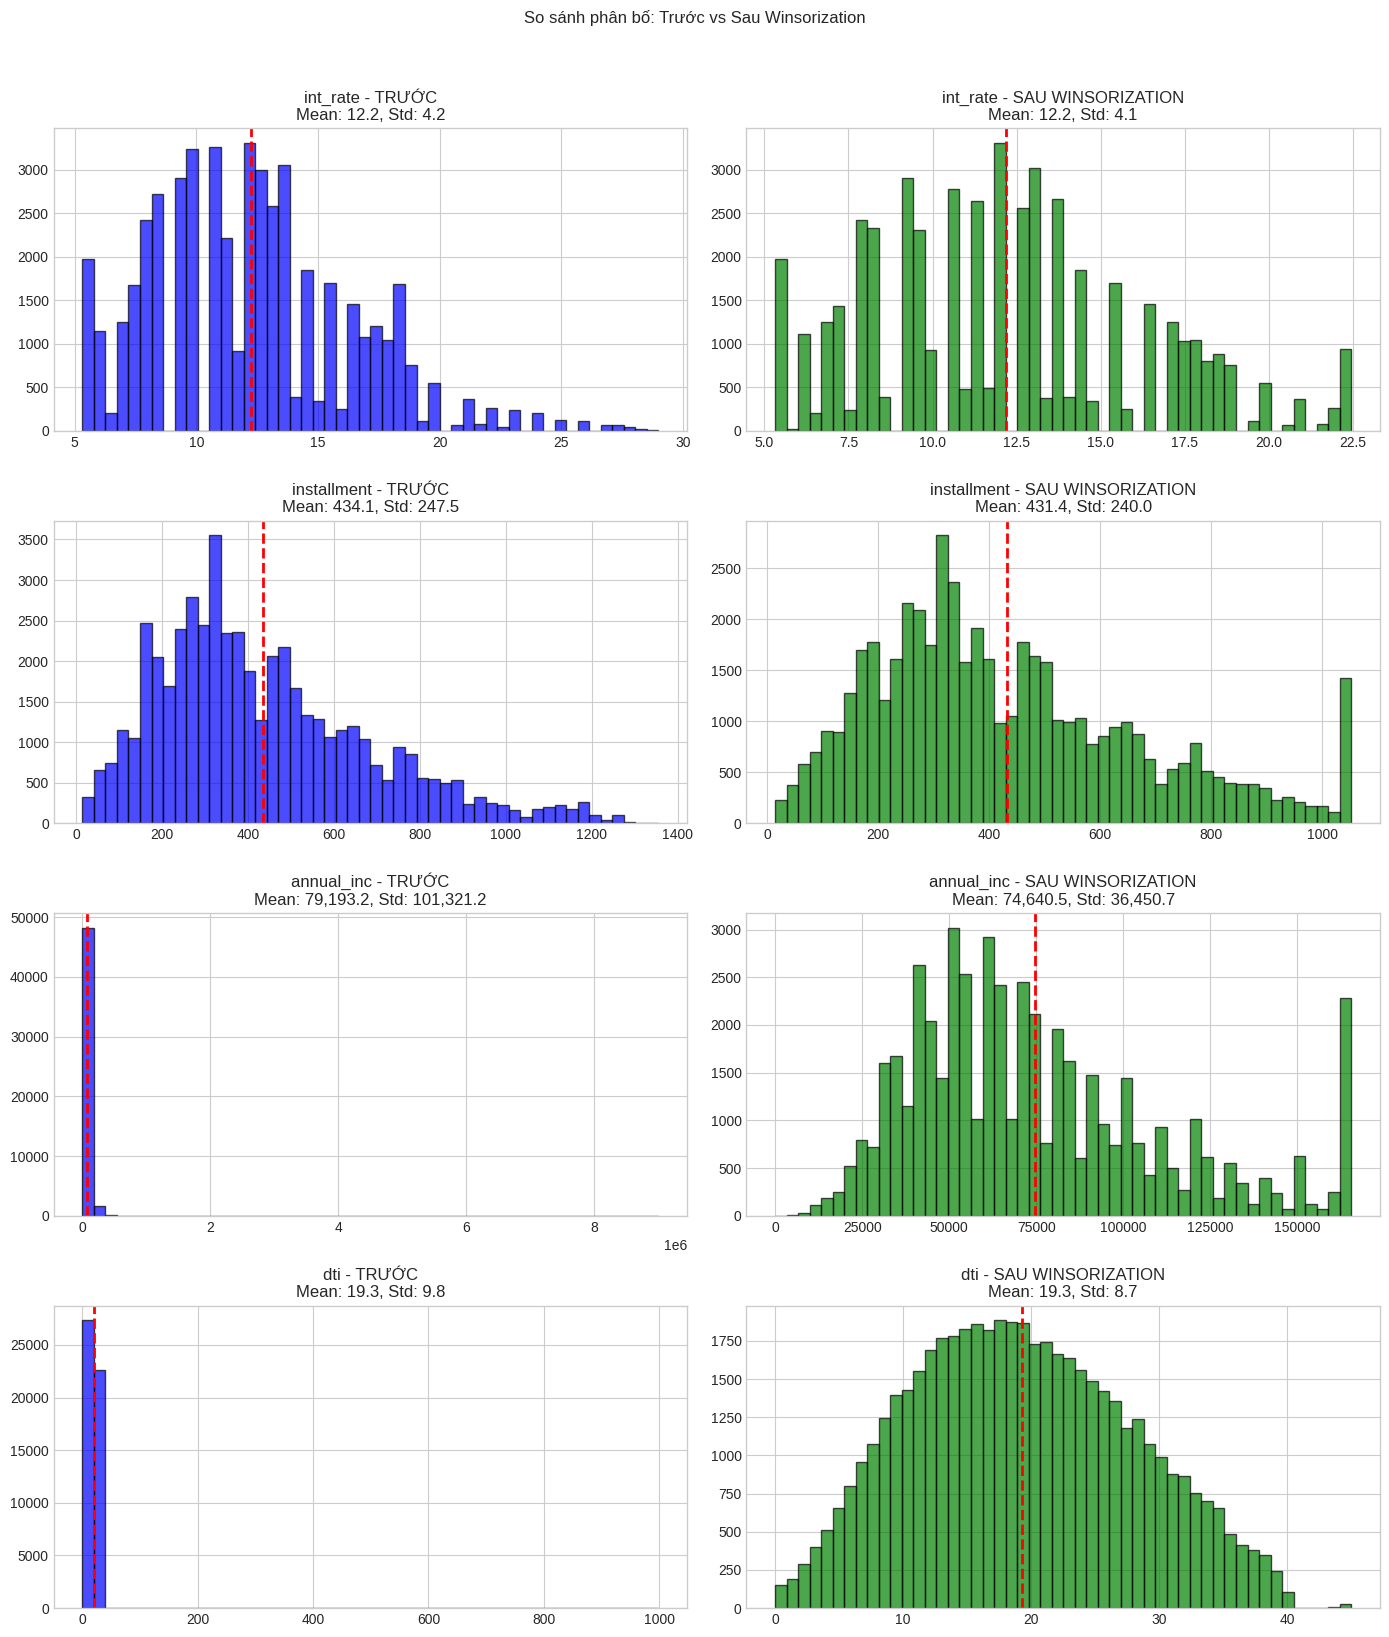

In [10]:
# Visualize trước và sau
cols_with_changes = [c['Biến'] for c in changes_made] if changes_made else num_cols[:4]
n_plots = min(4, len(cols_with_changes))

if n_plots > 0:
    fig, axes = plt.subplots(n_plots, 2, figsize=(14, 4*n_plots))
    if n_plots == 1:
        axes = axes.reshape(1, -1)
    
    for i, col in enumerate(cols_with_changes[:n_plots]):
        before = df[col].dropna()
        after = df_clean[col].dropna()
        
        # Trước
        ax = axes[i, 0]
        ax.hist(before, bins=50, alpha=0.7, color='blue', edgecolor='black')
        ax.axvline(before.mean(), color='red', linestyle='--', linewidth=2)
        ax.set_title(f'{col} - TRƯỚC\nMean: {before.mean():,.1f}, Std: {before.std():,.1f}')
        
        # Sau
        ax = axes[i, 1]
        ax.hist(after, bins=50, alpha=0.7, color='green', edgecolor='black')
        ax.axvline(after.mean(), color='red', linestyle='--', linewidth=2)
        ax.set_title(f'{col} - SAU WINSORIZATION\nMean: {after.mean():,.1f}, Std: {after.std():,.1f}')
    
    plt.suptitle('So sánh phân bố: Trước vs Sau Winsorization', y=1.02, fontsize=12)
    plt.tight_layout()
    plt.savefig('outputs/07_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7.9 Lưu biên outliers

In [11]:
# Lưu thông tin biên để sử dụng sau
bounds_df = pd.DataFrame(outlier_bounds).T
bounds_df.columns = ['lower_bound', 'upper_bound']
bounds_df.to_csv('outputs/outlier_bounds.csv')

print("=" * 70)
print("💾 ĐÃ LƯU OUTLIER BOUNDS")
print("=" * 70)
print(bounds_df.round(2))
print("\n💾 File: outputs/outlier_bounds.csv")

💾 ĐÃ LƯU OUTLIER BOUNDS
             lower_bound  upper_bound
loan_amnt      -10000.00     38000.00
int_rate            1.20        22.44
installment      -222.95      1051.70
annual_inc     -22500.00    165500.00
dti                -6.72        45.02
open_acc           -2.50        25.50
revol_bal      -16399.88     43973.12
revol_util        -20.50       125.10
total_acc          -5.50        54.50

💾 File: outputs/outlier_bounds.csv


## 7.10 Tổng kết Bước 7

In [12]:
print("=" * 70)
print("📋 TỔNG KẾT BƯỚC 7: XỬ LÝ NGOẠI LỆ")
print("=" * 70)

# Tính metrics thực từ dữ liệu
total_changes = sum(c['Tổng thay đổi'] for c in changes_made) if changes_made else 0

print(f"""
✅ ĐÃ HOÀN THÀNH:
   • Phát hiện outliers bằng IQR cho {len(num_cols)} biến
   • Tổng outliers phát hiện: {total_outliers_all:,}
   • Biến nhiều outliers nhất: {max_outlier_col} ({max_outlier_pct:.2f}%)
   • Áp dụng Winsorization: {total_changes:,} giá trị đã điều chỉnh

📊 CHI TIẾT OUTLIERS THEO BIẾN:
""")

for _, row in outlier_df.iterrows():
    if row['Tỷ lệ %'] > 0:
        pct = row['Tỷ lệ %']
        indicator = "🔴" if pct > 3 else "🟡" if pct > 1 else "🟢"
        print(f"   {indicator} {row['Cột']}: {row['Tổng outliers']:,} ({pct:.2f}%)")

print(f"""
💡 INSIGHT:
   • annual_inc có nhiều outliers cao (người thu nhập rất cao)
   • int_rate và installment có outliers ở cận trên
   • Sau winsorization, dữ liệu ổn định hơn cho modeling

📝 BƯỚC TIẾP THEO:
   → Bước 8: Truyền đạt phát hiện và hiểu biết sâu sắc
""")

# Lưu dataframe
df_clean.to_pickle('outputs/df_step7.pkl')
print("💾 Đã lưu: outputs/df_step7.pkl")

📋 TỔNG KẾT BƯỚC 7: XỬ LÝ NGOẠI LỆ

✅ ĐÃ HOÀN THÀNH:
   • Phát hiện outliers bằng IQR cho 9 biến
   • Tổng outliers phát hiện: 10,028
   • Biến nhiều outliers nhất: revol_bal (6.15%)
   • Áp dụng Winsorization: 10,029 giá trị đã điều chỉnh

📊 CHI TIẾT OUTLIERS THEO BIẾN:

   🟡 int_rate: 941 (1.88%)
   🟡 installment: 1,332 (2.66%)
   🔴 annual_inc: 2,146 (4.29%)
   🟢 dti: 28 (0.06%)
   🟡 open_acc: 1,359 (2.72%)
   🔴 revol_bal: 3,077 (6.15%)
   🟢 revol_util: 4 (0.01%)
   🟡 total_acc: 1,141 (2.28%)

💡 INSIGHT:
   • annual_inc có nhiều outliers cao (người thu nhập rất cao)
   • int_rate và installment có outliers ở cận trên
   • Sau winsorization, dữ liệu ổn định hơn cho modeling

📝 BƯỚC TIẾP THEO:
   → Bước 8: Truyền đạt phát hiện và hiểu biết sâu sắc

💾 Đã lưu: outputs/df_step7.pkl
